In [1]:
import json
import pandas as pd
from os import path as osp

In [ ]:
data_dir = osp.abspath('../data')
print(data_dir)

In [3]:
in_file = 'color_grid_data.json'
in_path = osp.join(data_dir, in_file)
data_df = pd.read_json(in_path)

n_games = len(data_df.gameid.unique())

data_df.head()

,gameid,game_idx,roundNum,round_id,condition,success,utterances,n_utterances,objs,target,speaker_order,listener_order,listener_clicked
0,4147-9d9582f2-28d0-431f-b6ba-35fd1be76619,1,1,4147-9d9582f2-28d0-431f-b6ba-35fd1be76619_1,FAR,True,"[[speaker, green top left corner, 1528144087280]]",1,"[{'shapes': [{'color': [322, 21, 50]}, {'color...",1,"[2, 1, 0]","[1, 0, 2]",0
1,4147-9d9582f2-28d0-431f-b6ba-35fd1be76619,1,2,4147-9d9582f2-28d0-431f-b6ba-35fd1be76619_2,SPLIT,True,"[[speaker, pink in the bottom left, 1528144112...",1,"[{'shapes': [{'color': [55, 5, 50]}, {'color':...",2,"[2, 1, 0]","[0, 2, 1]",1
2,4147-9d9582f2-28d0-431f-b6ba-35fd1be76619,1,3,4147-9d9582f2-28d0-431f-b6ba-35fd1be76619_3,SPLIT,False,"[[speaker, dark orange top right corner, 15281...",1,"[{'shapes': [{'color': [206, 56, 50]}, {'color...",0,"[0, 1, 2]","[1, 2, 0]",1
3,4147-9d9582f2-28d0-431f-b6ba-35fd1be76619,1,4,4147-9d9582f2-28d0-431f-b6ba-35fd1be76619_4,FAR,True,"[[speaker, green in the middle square top row,...",1,"[{'shapes': [{'color': [294, 7, 50]}, {'color'...",0,"[1, 2, 0]","[2, 1, 0]",2
4,4147-9d9582f2-28d0-431f-b6ba-35fd1be76619,1,5,4147-9d9582f2-28d0-431f-b6ba-35fd1be76619_5,SPLIT,True,"[[speaker, top right corner red, 1528144188447]]",1,"[{'shapes': [{'color': [227, 76, 50]}, {'color...",1,"[0, 2, 1]","[1, 2, 0]",0


<Axes: ylabel='Frequency'>

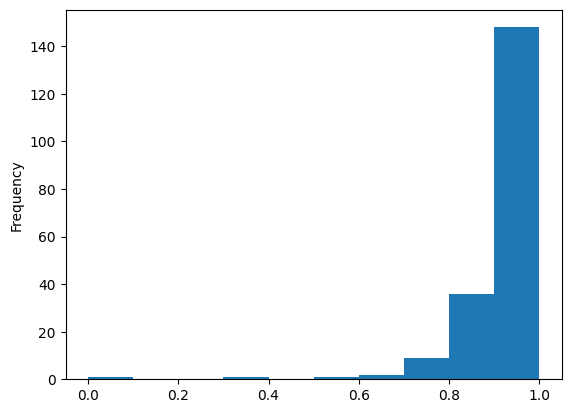

In [4]:
game_success_rate = data_df.groupby('gameid').success.mean()

game_success_rate.plot(kind='hist')

removed 16 games with success rate < 0.8 (total: 198, 8.1 % removed)


<Axes: ylabel='Frequency'>

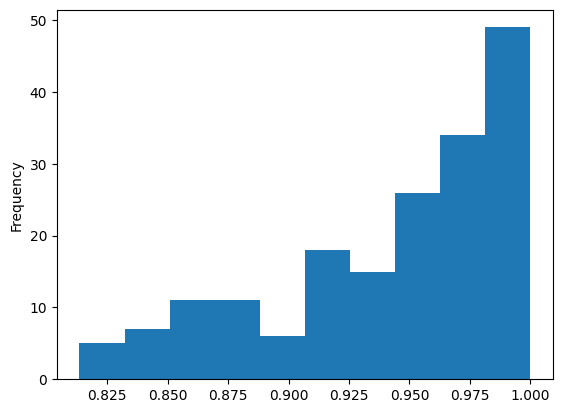

In [5]:
success_threshold = 0.8
m = game_success_rate > success_threshold
successful_games = game_success_rate[m].index.tolist()

n_removed_games = n_games - len(successful_games)
removed_perc = (n_removed_games / n_games) * 100
print(f'removed {n_removed_games} games with success rate < {success_threshold} (total: {n_games}, {round(removed_perc, 1)} % removed)')

game_success_rate.loc[successful_games].plot(kind='hist')

In [6]:
n_rounds_per_game = data_df.groupby('gameid').size()
m = n_rounds_per_game == 60

full_games = n_rounds_per_game[m].index.to_list()

print(f'missing rounds in {n_games - len(full_games)} of {n_games} games')

missing rounds in 29 of 198 games


In [7]:
successful_full_games = set(successful_games).intersection(set(full_games))
n_removed_games = n_games - len(successful_full_games)
removed_perc = (n_removed_games / n_games) * 100
print(f'filtered out {n_removed_games} games that were not full or below the success threshold (total: {n_games}, {round(removed_perc, 1)} % removed)')
print(f'# remaining games: {len(successful_full_games)} / {n_games}')

filtered out 37 games that were not full or below the success threshold (total: 198, 18.7 % removed)
# remaining games: 161 / 198


In [8]:
filtered_data = data_df.loc[data_df.gameid.isin(successful_full_games)]
filtered_gameids = set(filtered_data.gameid)
assert filtered_gameids == set(successful_full_games)

In [ ]:
out_file = 'filtered_gameids.json'
out_path = osp.join(data_dir, out_file)

print(f'save gameids to {out_path}')

with open(out_path, 'w') as f:
    json.dump(
        {'gameids': list(filtered_gameids)}, f
    )

In [10]:
import numpy as np
data_df.loc[np.logical_not(data_df.gameid.isin(full_games))].sort_values(by=['game_idx', 'roundNum'])

,gameid,game_idx,roundNum,round_id,condition,success,utterances,n_utterances,objs,target,speaker_order,listener_order,listener_clicked
60,3514-6cfc8b8b-11b8-45a4-b882-53d3d59f207f,2,1,3514-6cfc8b8b-11b8-45a4-b882-53d3d59f207f_1,CLOSE,False,"[[speaker, center box is GREEN, 1528148639709]...",4,"[{'shapes': [{'color': [247, 22, 50]}, {'color...",0,"[2, 0, 1]","[1, 0, 2]",0
61,3514-6cfc8b8b-11b8-45a4-b882-53d3d59f207f,2,2,3514-6cfc8b8b-11b8-45a4-b882-53d3d59f207f_2,CLOSE,True,"[[speaker, Brown in middle with green color bo...",5,"[{'shapes': [{'color': [27, 91, 50]}, {'color'...",0,"[2, 0, 1]","[1, 2, 0]",2
62,3514-6cfc8b8b-11b8-45a4-b882-53d3d59f207f,2,3,3514-6cfc8b8b-11b8-45a4-b882-53d3d59f207f_3,CLOSE,True,"[[speaker, TOP MIDDLE is BRIGHT red., 15281489...",1,"[{'shapes': [{'color': [109, 84, 50]}, {'color...",2,"[0, 2, 1]","[0, 2, 1]",1
63,3514-6cfc8b8b-11b8-45a4-b882-53d3d59f207f,2,4,3514-6cfc8b8b-11b8-45a4-b882-53d3d59f207f_4,CLOSE,True,"[[speaker, bottom right is bright red, 1528148...",5,"[{'shapes': [{'color': [58, 32, 50]}, {'color'...",2,"[2, 1, 0]","[2, 0, 1]",0
64,3514-6cfc8b8b-11b8-45a4-b882-53d3d59f207f,2,5,3514-6cfc8b8b-11b8-45a4-b882-53d3d59f207f_5,SPLIT,True,"[[speaker, CENTER BOX is medium GREEN. BOTT...",2,"[{'shapes': [{'color': [31, 77, 50]}, {'color'...",1,"[1, 2, 0]","[2, 0, 1]",2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10380,3030-33d15b15-58c2-49c4-9ab5-09f8d7379aee,189,5,3030-33d15b15-58c2-49c4-9ab5-09f8d7379aee_5,FAR,True,"[[speaker, the bottom row is blue, greenish-ye...",1,"[{'shapes': [{'color': [142, 0, 50]}, {'color'...",2,"[1, 2, 0]","[2, 0, 1]",0
10381,3030-33d15b15-58c2-49c4-9ab5-09f8d7379aee,189,6,3030-33d15b15-58c2-49c4-9ab5-09f8d7379aee_6,CLOSE,True,"[[speaker, left corner is brightest green, 152...",1,"[{'shapes': [{'color': [151, 56, 50]}, {'color...",1,"[1, 0, 2]","[1, 2, 0]",0
10382,3030-33d15b15-58c2-49c4-9ab5-09f8d7379aee,189,7,3030-33d15b15-58c2-49c4-9ab5-09f8d7379aee_7,SPLIT,True,"[[speaker, the bottom row is indigo, blue, dar...",1,"[{'shapes': [{'color': [125, 90, 50]}, {'color...",0,"[2, 1, 0]","[1, 2, 0]",2
10383,3030-33d15b15-58c2-49c4-9ab5-09f8d7379aee,189,8,3030-33d15b15-58c2-49c4-9ab5-09f8d7379aee_8,SPLIT,False,"[[speaker, the one with a blue square, 1526509...",1,"[{'shapes': [{'color': [74, 17, 50]}, {'color'...",1,"[2, 0, 1]","[2, 1, 0]",2
